In [ ]:
# pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 590.9 kB/s eta 0:00:41
    --------------------------------------- 0.5/24.4 MB 590.9 kB/s eta 0:00:41
   - -------------------------------------- 0.8/24.4 MB 631.8 kB/s eta 0:00:38
   - -------------------------------------- 0.8/24.4 MB 631.8 kB/s eta 0:00:38
   - -------------------------------------- 1.0/24.4 M


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences   
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from sklearn.model_selection import train_test_split

In [9]:
fake_df=pd.read_csv("Fake.csv")
real_df=pd.read_csv("True.csv")

fake_df["label"]=0
real_df["label"]=1

df=pd.concat([fake_df,real_df],ignore_index=True)

df=df[["text","label"]]

df.dropna(inplace=True)
df

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0
...,...,...
44893,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
44894,"LONDON (Reuters) - LexisNexis, a provider of l...",1
44895,MINSK (Reuters) - In the shadow of disused Sov...,1
44896,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [10]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"[^a-zA-Z\s]","",text)
    return text

df["clean_text"] = df["text"].apply(clean_text)


In [11]:
fake_text=" ".join(df[df["label"]==0]["clean_text"])
real_text=" ".join(df[df["label"]==1]["clean_text"])

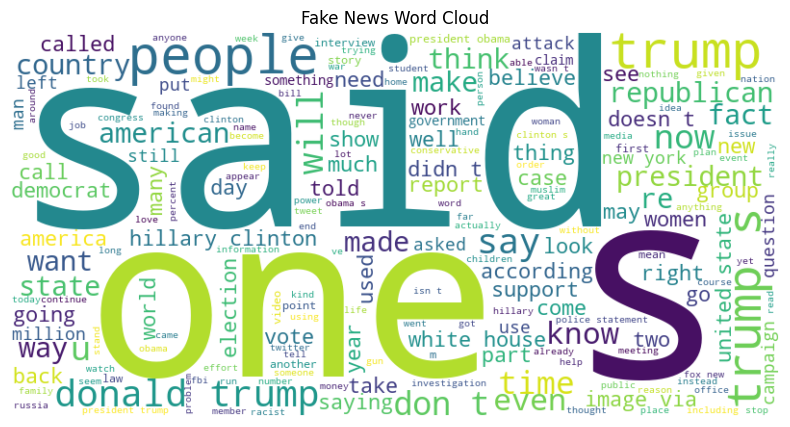

In [12]:
wc_fake=WordCloud(width=800,height=400,background_color="white").generate(fake_text)
plt.figure(figsize=(10,5))
plt.imshow(wc_fake,interpolation="bilinear")
plt.axis("off")
plt.title("Fake News Word Cloud")
plt.show()


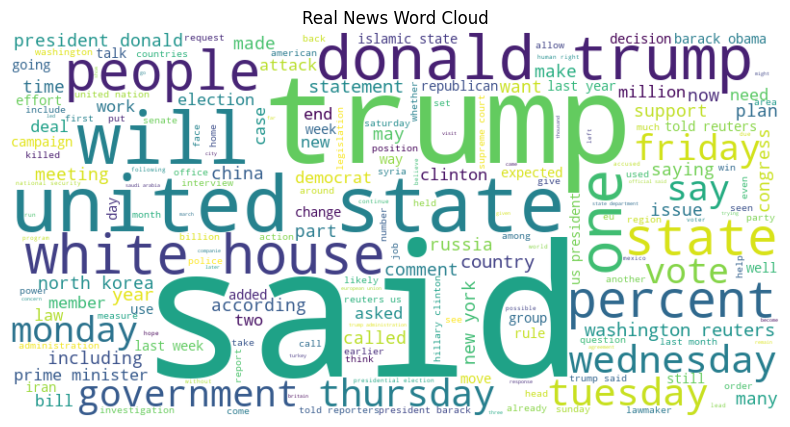

In [13]:
wc_real=WordCloud(width=800,height=400,background_color="white").generate(real_text)
plt.figure(figsize=(10,5))
plt.imshow(wc_real,interpolation="bilinear")
plt.axis("off")
plt.title("Real News Word Cloud")
plt.show()

In [14]:
vacob_size=10000
max_length=200

tokenizer=Tokenizer(num_words=vacob_size)
tokenizer.fit_on_texts(df["clean_text"])

X= tokenizer.texts_to_sequences(df["clean_text"])
X=pad_sequences(X,maxlen=max_length,padding="post")
y=df["label"].values



In [15]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
model=Sequential([
    Embedding(input_dim=vacob_size,output_dim=128,input_length=max_length),
    Bidirectional(LSTM(64,return_sequences=False)),
    Dropout(0.5),
    Dense(1,activation="sigmoid")
])

c:\Users\AKASH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"]) 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(x_train,y_train,epochs=1,batch_size=128,validation_split=0.2)

In [ ]:
loss,acc=model.evaluate(x_test,y_test)
print(f"Loss: {loss:.2f}, Accuracy: {acc:.2f}")

In [ ]:
def predict_news(text):
    text=clean_text(text)
    seq=tokenizer.texts_to_sequences([text])
    padded=pad_sequences(seq,maxlen=max_length,padding="post")
    prediction=model.predict(padded)[0][0]
    return "Real" if prediction>0.5 else "Fake"

new_article="""the stock market is experiencing a significant downturn due to global economic uncertainties and rising inflation rates. Experts predict that this trend may continue in the coming months, affecting various industries and investor confidence."""

sample_text=df["text"].iloc[0]
print("prediction:",predict_news(sample_text))
